# 후보 주차별 평가 Feature 전처리

## 목적

- 후보 시점인 1·2·4주차까지 확인 가능한 평가 정보만 사용한다.
- 평가 미제출 학생도 전체 예측 대상에서 제외하지 않는다.
- 미래 제출일·미래 점수 등 데이터 누출을 방지한다.
- VLE Snapshot과 학생·강좌 단위로 Left Join한다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

ASSESSMENTS_PATH = RAW_DIR / "assessments.csv"
STUDENT_ASSESSMENT_PATH = RAW_DIR / "studentAssessment.csv"

SNAPSHOT_PATHS = {
    1: INTERIM_DIR / "vle_snapshot_week_1.csv",
    2: INTERIM_DIR / "vle_snapshot_week_2.csv",
    4: INTERIM_DIR / "vle_snapshot_week_4.csv"
}

print("assessments:", ASSESSMENTS_PATH.exists())
print(
    "studentAssessment:",
    STUDENT_ASSESSMENT_PATH.exists()
)

for week, path in SNAPSHOT_PATHS.items():
    print(f"{week}주차 VLE Snapshot:", path.exists())

assessments: True
studentAssessment: True
1주차 VLE Snapshot: True
2주차 VLE Snapshot: True
4주차 VLE Snapshot: True


In [2]:
assessments = pd.read_csv(
    ASSESSMENTS_PATH,
    na_values=["?"]
)

student_assessment = pd.read_csv(
    STUDENT_ASSESSMENT_PATH,
    na_values=["?"]
)

vle_snapshots = {
    week: pd.read_csv(path)
    for week, path in SNAPSHOT_PATHS.items()
}

print("assessments:", assessments.shape)
print("studentAssessment:", student_assessment.shape)

for week, snapshot in vle_snapshots.items():
    print(f"{week}주차 Snapshot:", snapshot.shape)

assessments: (206, 6)
studentAssessment: (173912, 5)
1주차 Snapshot: (29018, 66)
2주차 Snapshot: (27984, 66)
4주차 Snapshot: (27449, 66)


In [3]:
print("===== assessments 컬럼 =====")
print(assessments.columns.tolist())
print(assessments.dtypes)

print("\n===== studentAssessment 컬럼 =====")
print(student_assessment.columns.tolist())
print(student_assessment.dtypes)

print("\n===== assessments 결측치 =====")
print(assessments.isna().sum())

print("\n===== studentAssessment 결측치 =====")
print(student_assessment.isna().sum())

ASSESSMENT_NUMERIC_COLUMNS = [
    "id_assessment",
    "date",
    "weight"
]

for column in ASSESSMENT_NUMERIC_COLUMNS:
    assessments[column] = pd.to_numeric(
        assessments[column],
        errors="coerce"
    )

STUDENT_ASSESSMENT_NUMERIC_COLUMNS = [
    "id_assessment",
    "id_student",
    "date_submitted",
    "is_banked",
    "score"
]

for column in STUDENT_ASSESSMENT_NUMERIC_COLUMNS:
    student_assessment[column] = pd.to_numeric(
        student_assessment[column],
        errors="coerce"
    )

print(
    "assessments 평가 ID 중복:",
    assessments.duplicated(
        ["id_assessment"]
    ).sum()
)

print(
    "studentAssessment 학생-평가 중복:",
    student_assessment.duplicated(
        ["id_assessment", "id_student"]
    ).sum()
)

print("\n평가 유형별 개수:")
display(
    assessments["assessment_type"]
    .value_counts(dropna=False)
    .rename_axis("assessment_type")
    .reset_index(name="assessment_count")
)

print("\n평가 유형별 날짜 결측:")
display(
    assessments
    .groupby("assessment_type", dropna=False)
    .agg(
        assessment_count=("id_assessment", "size"),
        missing_date=("date", lambda values: values.isna().sum()),
        weight_sum=("weight", "sum")
    )
    .reset_index()
)

===== assessments 컬럼 =====
['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
code_module              str
code_presentation        str
id_assessment          int64
assessment_type          str
date                 float64
weight               float64
dtype: object

===== studentAssessment 컬럼 =====
['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']
id_assessment       int64
id_student          int64
date_submitted      int64
is_banked           int64
score             float64
dtype: object

===== assessments 결측치 =====
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

===== studentAssessment 결측치 =====
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64
assessments 평가 ID 중복: 0
studentAssessment 학생-평가 중복: 0

평가 유형별 개수:


,assessment_type,assessment_count
0,TMA,106
1,CMA,76
2,Exam,24



평가 유형별 날짜 결측:


,assessment_type,assessment_count,missing_date,weight_sum
0,CMA,76,0,90.0
1,Exam,24,11,2400.0
2,TMA,106,0,1810.0


In [4]:
assessment_events = student_assessment.merge(
    assessments,
    on="id_assessment",
    how="left",
    validate="many_to_one",
    indicator="metadata_merge"
)

print("병합 전 학생 평가 행:", len(student_assessment))
print("병합 후 학생 평가 행:", len(assessment_events))

print("\n평가 정보 연결 결과:")
print(
    assessment_events["metadata_merge"]
    .value_counts()
)

assessment_events = assessment_events.drop(
    columns="metadata_merge"
)

# 점수 결측 여부
assessment_events["score_missing"] = (
    assessment_events["score"].isna()
).astype(int)

assessment_events["has_score"] = (
    assessment_events["score"].notna()
).astype(int)

# 제출일 - 평가 마감일
# 음수: 마감 전 제출, 양수: 지각 제출
assessment_events["submission_gap"] = (
    assessment_events["date_submitted"]
    - assessment_events["date"]
)

# 이월된 평가(is_banked)는 현재 강좌의 지각 제출로 보지 않음
assessment_events["is_late_submission"] = (
    assessment_events["date"].notna()
    & assessment_events["submission_gap"].gt(0)
    & assessment_events["is_banked"].eq(0)
).astype(int)

print(
    "평가 정보 연결 실패:",
    assessment_events["code_module"].isna().sum()
)
print(
    "제출일 범위:",
    assessment_events["date_submitted"].min(),
    "~",
    assessment_events["date_submitted"].max()
)
print(
    "점수 범위:",
    assessment_events["score"].min(),
    "~",
    assessment_events["score"].max()
)
print(
    "점수 결측:",
    assessment_events["score_missing"].sum()
)
print(
    "이월 평가:",
    assessment_events["is_banked"].sum()
)
print(
    "지각 제출:",
    assessment_events["is_late_submission"].sum()
)

availability_rows = []

for cutoff_week in [1, 2, 4]:
    cutoff_day = cutoff_week * 7 - 1

    # 해당 시점까지 마감된 평가
    due_assessments = assessments.loc[
        assessments["date"].notna()
        & assessments["date"].le(cutoff_day)
    ]

    # 해당 시점까지 실제 제출된 학생 평가
    known_submissions = assessment_events.loc[
        assessment_events["date_submitted"]
        .le(cutoff_day)
    ]

    availability_rows.append({
        "cutoff_week": cutoff_week,
        "cutoff_day": cutoff_day,
        "due_assessment_count": len(due_assessments),
        "known_submission_rows": len(known_submissions),
        "known_nonbanked_rows": (
            known_submissions["is_banked"].eq(0).sum()
        ),
        "known_banked_rows": (
            known_submissions["is_banked"].eq(1).sum()
        )
    })

assessment_availability = pd.DataFrame(
    availability_rows
)

display(assessment_availability)

병합 전 학생 평가 행: 173912
병합 후 학생 평가 행: 173912

평가 정보 연결 결과:
metadata_merge
both          173912
left_only          0
right_only         0
Name: count, dtype: int64
평가 정보 연결 실패: 0
제출일 범위: -11 ~ 608
점수 범위: 0.0 ~ 100.0
점수 결측: 173
이월 평가: 1909
지각 제출: 49318


,cutoff_week,cutoff_day,due_assessment_count,known_submission_rows,known_nonbanked_rows,known_banked_rows
0,1,6,0,2778,869,1909
1,2,13,1,5191,3282,1909
2,4,27,17,25348,23439,1909


In [5]:
import numpy as np
import pandas as pd
from pathlib import Path

KEY_COLS = [
    "code_module",
    "code_presentation",
    "id_student"
]


def build_assessment_features(snapshot, cutoff_week):
    cutoff_day = cutoff_week * 7 - 1

    # 예측 대상 학생-강좌 명단
    student_courses = snapshot[KEY_COLS].drop_duplicates().copy()

    # 해당 시점까지 마감된 평가
    due_assessments = assessments.loc[
        assessments["date"].notna()
        & (assessments["date"] <= cutoff_day)
    ].copy()

    # 학생-강좌와 마감 평가 연결
    schedule = student_courses.merge(
        due_assessments,
        on=["code_module", "code_presentation"],
        how="left"
    )

    schedule["id_assessment"] = (
        schedule["id_assessment"].astype("Int64")
    )

    # 해당 시점까지 실제로 확인 가능한 제출 기록만 사용
    known_submissions = assessment_events.loc[
        assessment_events["date_submitted"] <= cutoff_day,
        [
            "id_assessment",
            "id_student",
            "date_submitted",
            "is_banked",
            "score"
        ]
    ].copy()

    known_submissions["id_assessment"] = (
        known_submissions["id_assessment"].astype("Int64")
    )

    schedule = schedule.merge(
        known_submissions,
        on=["id_assessment", "id_student"],
        how="left",
        validate="many_to_one"
    )

    # 기본 여부 Feature
    schedule["is_due"] = (
        schedule["id_assessment"].notna().astype(int)
    )

    schedule["submitted_due"] = (
        schedule["is_due"].eq(1)
        & schedule["date_submitted"].notna()
    ).astype(int)

    schedule["scored_due"] = (
        schedule["submitted_due"].eq(1)
        & schedule["score"].notna()
    ).astype(int)

    schedule["score_missing_due"] = (
        schedule["submitted_due"].eq(1)
        & schedule["score"].isna()
    ).astype(int)

    schedule["banked_due"] = (
        schedule["submitted_due"].eq(1)
        & schedule["is_banked"].eq(1)
    ).astype(int)

    schedule["late_due"] = (
        schedule["submitted_due"].eq(1)
        & schedule["date"].notna()
        & schedule["date_submitted"].gt(schedule["date"])
        & schedule["is_banked"].eq(0)
    ).astype(int)

    schedule["nonbanked_submitted"] = (
        schedule["submitted_due"].eq(1)
        & schedule["is_banked"].eq(0)
    ).astype(int)

    # 점수 계산용 컬럼
    schedule["score_for_stats"] = schedule["score"].where(
        schedule["scored_due"].eq(1)
    )

    schedule["weighted_score_part"] = (
        schedule["score"] * schedule["weight"]
    ).where(schedule["scored_due"].eq(1))

    schedule["scored_weight"] = schedule["weight"].where(
        schedule["scored_due"].eq(1)
    )

    schedule["submission_gap"] = (
        schedule["date_submitted"] - schedule["date"]
    ).where(schedule["nonbanked_submitted"].eq(1))

    # 평가 유형별 개수
    for assessment_type in ["TMA", "CMA", "Exam"]:
        name = assessment_type.lower()

        schedule[f"due_{name}"] = (
            schedule["is_due"].eq(1)
            & schedule["assessment_type"].eq(assessment_type)
        ).astype(int)

        schedule[f"submitted_{name}"] = (
            schedule["submitted_due"].eq(1)
            & schedule["assessment_type"].eq(assessment_type)
        ).astype(int)

    # 학생-강좌별 집계
    assessment_features = (
        schedule
        .groupby(KEY_COLS, as_index=False)
        .agg(
            assessment_due_count=("is_due", "sum"),
            assessment_due_weight=("weight", "sum"),
            assessment_submitted_due_count=("submitted_due", "sum"),
            assessment_scored_due_count=("scored_due", "sum"),
            assessment_missing_score_count=("score_missing_due", "sum"),
            assessment_banked_due_count=("banked_due", "sum"),
            assessment_late_count=("late_due", "sum"),
            assessment_nonbanked_submitted_count=(
                "nonbanked_submitted", "sum"
            ),
            assessment_mean_score=("score_for_stats", "mean"),
            assessment_median_score=("score_for_stats", "median"),
            assessment_min_score=("score_for_stats", "min"),
            assessment_max_score=("score_for_stats", "max"),
            weighted_score_sum=("weighted_score_part", "sum"),
            scored_weight_sum=("scored_weight", "sum"),
            assessment_mean_submission_gap=("submission_gap", "mean"),
            assessment_median_submission_gap=("submission_gap", "median"),
            assessment_due_tma_count=("due_tma", "sum"),
            assessment_submitted_tma_count=("submitted_tma", "sum"),
            assessment_due_cma_count=("due_cma", "sum"),
            assessment_submitted_cma_count=("submitted_cma", "sum"),
            assessment_due_exam_count=("due_exam", "sum"),
            assessment_submitted_exam_count=("submitted_exam", "sum")
        )
    )

    # 파생 비율
    assessment_features["assessment_missing_due_count"] = (
        assessment_features["assessment_due_count"]
        - assessment_features["assessment_submitted_due_count"]
    )

    assessment_features["assessment_submission_rate"] = (
        assessment_features["assessment_submitted_due_count"]
        / assessment_features["assessment_due_count"].replace(0, np.nan)
    ).fillna(0)

    assessment_features["assessment_missing_due_rate"] = (
        assessment_features["assessment_missing_due_count"]
        / assessment_features["assessment_due_count"].replace(0, np.nan)
    ).fillna(0)

    assessment_features["assessment_late_rate"] = (
        assessment_features["assessment_late_count"]
        / assessment_features[
            "assessment_nonbanked_submitted_count"
        ].replace(0, np.nan)
    ).fillna(0)

    assessment_features["assessment_weighted_mean_score"] = (
        assessment_features["weighted_score_sum"]
        / assessment_features["scored_weight_sum"].replace(0, np.nan)
    ).fillna(0)

    # 아직 마감되지 않았더라도 이미 제출한 기록
    all_known = assessment_events.loc[
        assessment_events["date_submitted"] <= cutoff_day
    ].copy()

    all_known["known_score_missing"] = (
        all_known["score"].isna().astype(int)
    )

    all_known["known_banked"] = (
        all_known["is_banked"].eq(1).astype(int)
    )

    all_known_features = (
        all_known
        .groupby(KEY_COLS, as_index=False)
        .agg(
            any_known_submission_count=("id_assessment", "size"),
            any_known_scored_count=("score", "count"),
            any_known_score_missing_count=(
                "known_score_missing", "sum"
            ),
            any_known_banked_count=("known_banked", "sum"),
            any_known_mean_score=("score", "mean"),
            any_known_median_score=("score", "median")
        )
    )

    assessment_features = assessment_features.merge(
        all_known_features,
        on=KEY_COLS,
        how="left",
        validate="one_to_one"
    )

    assessment_feature_cols = [
        col for col in assessment_features.columns
        if col not in KEY_COLS
    ]

    assessment_features[assessment_feature_cols] = (
        assessment_features[assessment_feature_cols].fillna(0)
    )

    # 기존 VLE Snapshot에 평가 Feature 연결
    final_snapshot = snapshot.merge(
        assessment_features,
        on=KEY_COLS,
        how="left",
        validate="one_to_one"
    )

    final_snapshot[assessment_feature_cols] = (
        final_snapshot[assessment_feature_cols].fillna(0)
    )

    return final_snapshot, assessment_features

In [6]:
week4_final, week4_assessment_features = (
    build_assessment_features(
        snapshot=vle_snapshots[4],
        cutoff_week=4
    )
)

print("기존 4주차 행 수:", len(vle_snapshots[4]))
print("평가 병합 후 행 수:", len(week4_final))

print(
    "키 중복:",
    week4_final.duplicated(KEY_COLS).sum()
)

assessment_cols = [
    col for col in week4_final.columns
    if col.startswith("assessment_")
    or col.startswith("any_known_")
]

print(
    "평가 Feature 전체 결측치:",
    week4_final[assessment_cols].isna().sum().sum()
)

print(
    "마감 평가가 있는 학생-강좌:",
    week4_final["assessment_due_count"].gt(0).sum()
)

print(
    "제출 기록이 확인된 학생-강좌:",
    week4_final["any_known_submission_count"].gt(0).sum()
)

display(
    week4_final[
        KEY_COLS
        + [
            "target",
            "assessment_due_count",
            "assessment_submitted_due_count",
            "assessment_missing_due_count",
            "assessment_submission_rate",
            "assessment_mean_score",
            "assessment_late_count",
            "any_known_submission_count"
        ]
    ].head(10)
)

기존 4주차 행 수: 27449
평가 병합 후 행 수: 27449
키 중복: 0
평가 Feature 전체 결측치: 0
마감 평가가 있는 학생-강좌: 22466
제출 기록이 확인된 학생-강좌: 20253


,code_module,code_presentation,id_student,target,assessment_due_count,assessment_submitted_due_count,assessment_missing_due_count,assessment_submission_rate,assessment_mean_score,assessment_late_count,any_known_submission_count
0,AAA,2013J,11391,0,1,1,0,1.0,78.0,0,1.0
1,AAA,2013J,28400,0,1,1,0,1.0,70.0,1,1.0
2,AAA,2013J,31604,0,1,1,0,1.0,72.0,0,1.0
3,AAA,2013J,32885,0,1,1,0,1.0,69.0,1,1.0
4,AAA,2013J,38053,0,1,1,0,1.0,79.0,0,1.0
5,AAA,2013J,45462,0,1,1,0,1.0,70.0,1,1.0
6,AAA,2013J,45642,0,1,1,0,1.0,72.0,0,1.0
7,AAA,2013J,52130,0,1,1,0,1.0,72.0,0,1.0
8,AAA,2013J,53025,0,1,1,0,1.0,71.0,0,1.0
9,AAA,2013J,57506,0,1,1,0,1.0,68.0,0,1.0


In [7]:
model_snapshots = {}
validation_result = []

LEAKAGE_COLUMNS = {
    "final_result",
    "date_unregistration",
    "unregister_yn",
    "pre_course_unregister_yn",
    "unregister_week"
}

for cutoff_week in [1, 2, 4]:
    final_snapshot, assessment_feature_table = (
        build_assessment_features(
            snapshot=vle_snapshots[cutoff_week],
            cutoff_week=cutoff_week
        )
    )

    model_snapshots[cutoff_week] = final_snapshot

    found_leakage = sorted(
        LEAKAGE_COLUMNS.intersection(final_snapshot.columns)
    )

    validation_result.append({
        "cutoff_week": cutoff_week,
        "row_count": len(final_snapshot),
        "column_count": final_snapshot.shape[1],
        "key_duplicates": final_snapshot.duplicated(KEY_COLS).sum(),
        "total_missing": final_snapshot.isna().sum().sum(),
        "target_1_count": int(final_snapshot["target"].sum()),
        "due_available_count": int(
            final_snapshot["assessment_due_count"].gt(0).sum()
        ),
        "known_submission_count": int(
            final_snapshot[
                "any_known_submission_count"
            ].gt(0).sum()
        ),
        "leakage_columns": found_leakage
    })

validation_df = pd.DataFrame(validation_result)

display(validation_df)

# 반드시 통과해야 하는 검증
for cutoff_week, final_snapshot in model_snapshots.items():
    assert len(final_snapshot) == len(vle_snapshots[cutoff_week])
    assert final_snapshot.duplicated(KEY_COLS).sum() == 0
    assert final_snapshot.isna().sum().sum() == 0
    assert not LEAKAGE_COLUMNS.intersection(final_snapshot.columns)

print("모든 주차 Snapshot 검증 통과")

,cutoff_week,row_count,column_count,key_duplicates,total_missing,target_1_count,due_available_count,known_submission_count,leakage_columns
0,1,29018,99,0,0,6652,0,1272,[]
1,2,27984,99,0,0,5589,1287,3472,[]
2,4,27449,99,0,0,5025,22466,20253,[]


모든 주차 Snapshot 검증 통과


In [8]:
from pathlib import Path

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

saved_files = []

for cutoff_week, snapshot in model_snapshots.items():
    output_path = (
        PROCESSED_DIR
        / f"model_snapshot_week_{cutoff_week}.csv"
    )

    snapshot.to_csv(
        output_path,
        index=False
    )

    saved_files.append({
        "cutoff_week": cutoff_week,
        "file_name": output_path.name,
        "row_count": len(snapshot),
        "column_count": snapshot.shape[1],
        "file_size_mb": round(
            output_path.stat().st_size / 1024**2,
            2
        )
    })

saved_files_df = pd.DataFrame(saved_files)

display(saved_files_df)
print("최종 머신러닝용 Snapshot 저장 완료")

,cutoff_week,file_name,row_count,column_count,file_size_mb
0,1,model_snapshot_week_1.csv,29018,99,12.64
1,2,model_snapshot_week_2.csv,27984,99,13.18
2,4,model_snapshot_week_4.csv,27449,99,13.62


최종 머신러닝용 Snapshot 저장 완료


In [9]:
assessment_eda_rows = []

for cutoff_week, snapshot in model_snapshots.items():
    for target_value in [0, 1]:
        group = snapshot.loc[
            snapshot["target"] == target_value
        ].copy()

        # 마감된 평가가 존재하는 학생-강좌
        due_group = group.loc[
            group["assessment_due_count"] > 0
        ]

        # 점수가 실제로 확인된 학생-강좌
        scored_group = group.loc[
            group["any_known_scored_count"] > 0
        ]

        # 일반 제출 기록이 있는 학생-강좌
        submitted_group = group.loc[
            group["assessment_nonbanked_submitted_count"] > 0
        ]

        assessment_eda_rows.append({
            "cutoff_week": cutoff_week,
            "target_label": (
                "Future withdrawn"
                if target_value == 1
                else "Non-withdrawn"
            ),
            "student_course_count": len(group),

            "due_available_pct": round(
                group["assessment_due_count"].gt(0).mean() * 100,
                2
            ),

            "known_submission_pct": round(
                group["any_known_submission_count"].gt(0).mean() * 100,
                2
            ),

            "no_known_submission_pct": round(
                group["any_known_submission_count"].eq(0).mean() * 100,
                2
            ),

            "median_known_submission_count": (
                group["any_known_submission_count"].median()
            ),

            # 점수가 존재하는 학생만 대상으로 비교
            "median_known_score": (
                scored_group["any_known_median_score"].median()
                if len(scored_group) > 0
                else np.nan
            ),

            "mean_known_score": (
                scored_group["any_known_mean_score"].mean()
                if len(scored_group) > 0
                else np.nan
            ),

            # 마감 평가가 있는 학생만 대상으로 비교
            "due_submission_rate_pct": (
                due_group["assessment_submission_rate"].mean() * 100
                if len(due_group) > 0
                else np.nan
            ),

            "due_missing_rate_pct": (
                due_group["assessment_missing_due_rate"].mean() * 100
                if len(due_group) > 0
                else np.nan
            ),

            # 일반 제출이 있는 학생만 대상으로 지각률 계산
            "late_rate_pct": (
                submitted_group["assessment_late_rate"].mean() * 100
                if len(submitted_group) > 0
                else np.nan
            )
        })

assessment_target_summary = pd.DataFrame(
    assessment_eda_rows
)

display(
    assessment_target_summary.round(2)
)

summary_columns = [
    "cutoff_week",
    "target_label",
    "due_available_pct",
    "known_submission_pct",
    "no_known_submission_pct",
    "median_known_submission_count",
    "median_known_score",
    "mean_known_score",
    "due_submission_rate_pct",
    "due_missing_rate_pct",
    "late_rate_pct"
]

print(
    assessment_target_summary[
        summary_columns
    ].round(2).to_string(index=False)
)

,cutoff_week,target_label,student_course_count,due_available_pct,known_submission_pct,no_known_submission_pct,median_known_submission_count,median_known_score,mean_known_score,due_submission_rate_pct,due_missing_rate_pct,late_rate_pct
0,1,Non-withdrawn,22366,0.00,4.67,95.33,0.0,81.0,74.03,NaN,NaN,NaN
1,1,Future withdrawn,6652,0.00,3.43,96.57,0.0,73.5,68.52,NaN,NaN,NaN
2,2,Non-withdrawn,22395,4.99,13.51,86.49,0.0,80.0,74.59,84.53,15.47,1.52
3,2,Future withdrawn,5589,3.02,8.00,92.00,0.0,73.0,69.63,73.37,26.63,4.31
4,4,Non-withdrawn,22424,80.14,74.41,25.59,1.0,78.0,74.72,91.34,8.66,21.00
5,4,Future withdrawn,5025,89.45,71.00,29.00,1.0,70.0,65.42,78.18,21.82,35.68


 cutoff_week     target_label  due_available_pct  known_submission_pct  no_known_submission_pct  median_known_submission_count  median_known_score  mean_known_score  due_submission_rate_pct  due_missing_rate_pct  late_rate_pct
           1    Non-withdrawn               0.00                  4.67                    95.33                            0.0                81.0             74.03                      NaN                   NaN            NaN
           1 Future withdrawn               0.00                  3.43                    96.57                            0.0                73.5             68.52                      NaN                   NaN            NaN
           2    Non-withdrawn               4.99                 13.51                    86.49                            0.0                80.0             74.59                    84.53                 15.47           1.52
           2 Future withdrawn               3.02                  8.00                    92

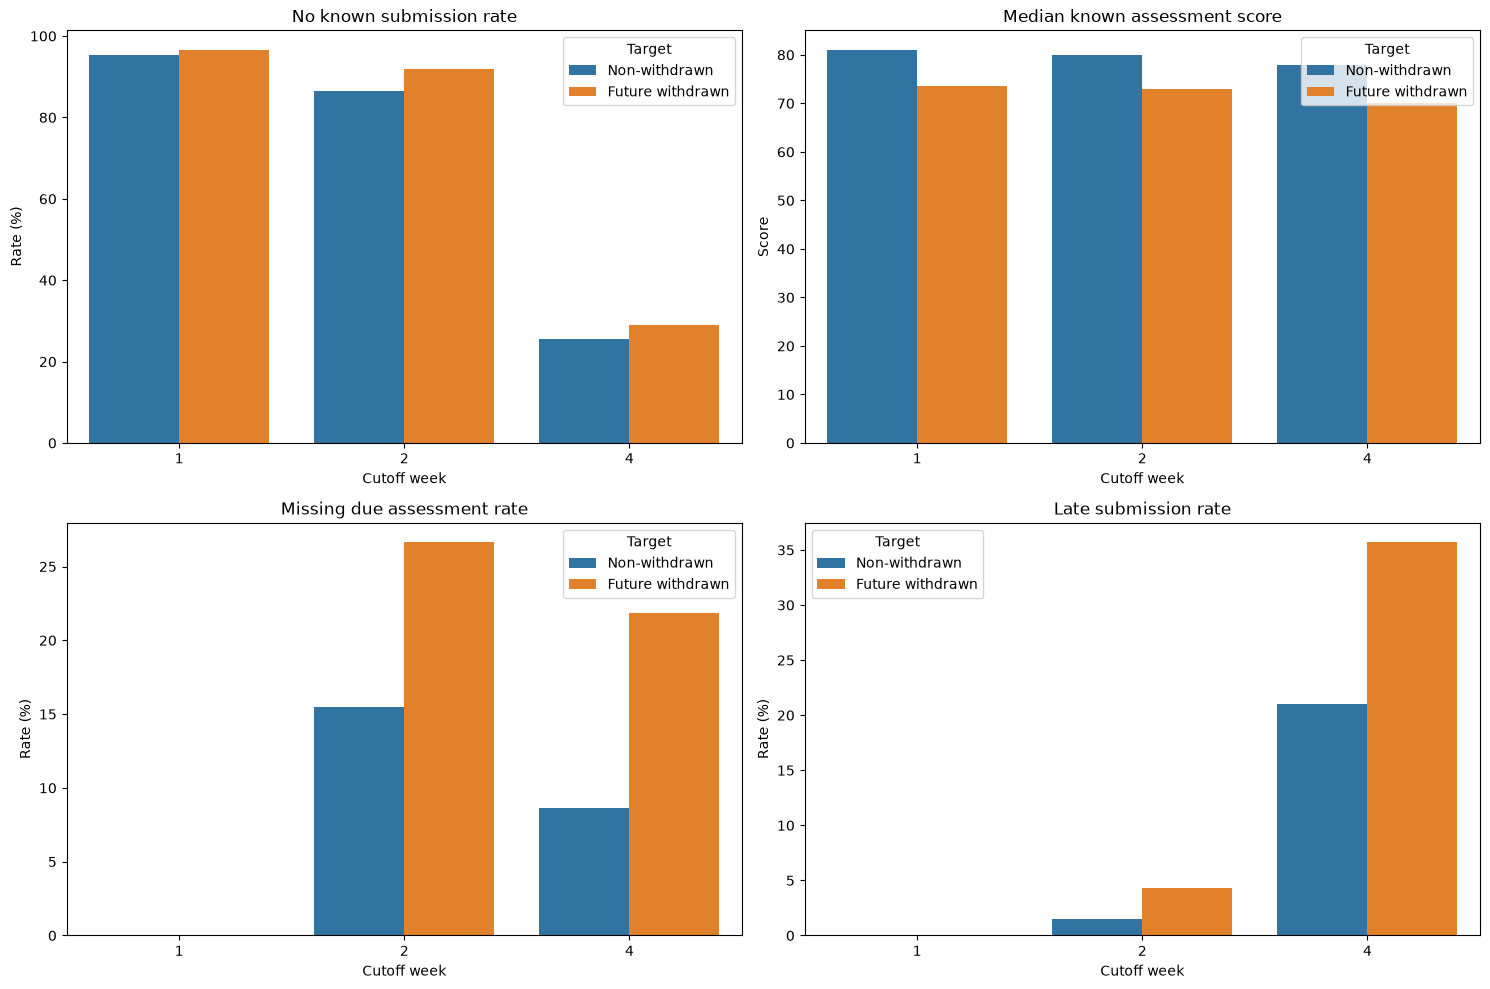

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = assessment_target_summary.copy()

fig, axes = plt.subplots(
    2, 2,
    figsize=(15, 10)
)

plot_settings = [
    (
        "no_known_submission_pct",
        "No known submission rate",
        "Rate (%)"
    ),
    (
        "median_known_score",
        "Median known assessment score",
        "Score"
    ),
    (
        "due_missing_rate_pct",
        "Missing due assessment rate",
        "Rate (%)"
    ),
    (
        "late_rate_pct",
        "Late submission rate",
        "Rate (%)"
    )
]

for ax, (column, title, ylabel) in zip(
    axes.flatten(),
    plot_settings
):
    sns.barplot(
        data=plot_data,
        x="cutoff_week",
        y=column,
        hue="target_label",
        hue_order=[
            "Non-withdrawn",
            "Future withdrawn"
        ],
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Cutoff week")
    ax.set_ylabel(ylabel)
    ax.legend(title="Target")

plt.tight_layout()
plt.show()

## 평가 데이터 EDA 결론

- 1주차에는 평가 제출 기록이 있는 학생이 매우 적어 평가 Feature만으로 조기 이탈을 예측하기 어렵다.
- 따라서 1주차 조기경보는 VLE 클릭량, 미활동 여부, 콘텐츠 접근 범위 등의 학습행동 Feature가 중심이 되어야 한다.
- 2주차부터 이탈 예정자의 제출률과 점수가 비이탈자보다 낮게 나타나기 시작하지만, 평가 데이터의 적용 범위는 아직 제한적이다.
- 4주차에는 이탈 예정자가 비이탈자보다 마감 평가 제출률이 낮고, 미제출률과 지각 제출률이 높으며, 평가 점수도 낮게 나타났다.
- 따라서 평가 Feature는 4주차 모델의 주요 보조 변수로 활용하고, 1·2주차 모델에서는 VLE Feature를 중심으로 사용한다.
- 과목마다 평가 일정이 다르므로 마감 평가 존재 여부 자체를 이탈 위험으로 직접 해석하지 않고, 과목 및 개설 회차 정보를 모델에 함께 포함한다.